## **TAREA 1 - ALEXIS BAUD & CLOTILDE GAND WATTEAU**

### **Terremotos: Análisis exploratorio de datos**

Hemos elegido el conjunto de datos de terremotos del USGS para analizar la evolución de la actividad sísmica a lo largo del tiempo. Con este análisis, buscamos responder al desafío central de la investigación: ¿Podemos afirmar, a partir de estos datos, que últimamente está temblando más?

EXPLORAR LOS DATOS

---



In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")

In [62]:
data = pd.read_csv("earthquakes_usgs.csv")
data.head()

,Unnamed: 0,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms
0,0,1900-01-05T19:00:00.000Z,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN
1,1,1900-01-11T09:07:00.000Z,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN
2,2,1900-01-20T06:33:00.000Z,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN
3,3,1900-01-31T19:22:00.000Z,48.0,146.0,450.0,7.5,mj,Sea of Okhotsk,earthquake,reviewed,cent,NaN,NaN
4,4,1900-04-30T22:41:14.000Z,36.9,-121.6,NaN,4.5,ml,"Near Aromas, California",earthquake,reviewed,ushis,NaN,NaN


El catálogo cuenta con variables espacio-temporales como la fecha (time), las coordenadas geográficas (latitude, longitude) y la profundidad (depth), junto con parámetros del sismo como la magnitud (mag) y su tipo (magType). También incluye metadatos de registro y control de calidad (place, type, status, net, nst, rms) que indican la procedencia y revisión de cada evento, pero no vamos a tanto utilizar.

In [63]:


data['datetime'] = pd.to_datetime(data['time'], format='ISO8601', errors='coerce')
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['hour'] = data['datetime'].dt.hour
data['decade'] = (data['year'] // 10) * 10

data['year_decimal'] = data['year'] + (data['datetime'].dt.dayofyear-1)/365.25

data = data.drop_duplicates()
#data = data[data["depth"] >= 0]
data = data.reset_index(drop=True)

min_mag = data["mag"].min()
print(min_mag)
data.head()

3.38


,Unnamed: 0,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms,datetime,year,month,day,hour,decade,year_decimal
0,0,1900-01-05T19:00:00.000Z,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN,1900-01-05 19:00:00+00:00,1900,1,5,19,1900,1900.010951
1,1,1900-01-11T09:07:00.000Z,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN,1900-01-11 09:07:00+00:00,1900,1,11,9,1900,1900.027379
2,2,1900-01-20T06:33:00.000Z,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN,1900-01-20 06:33:00+00:00,1900,1,20,6,1900,1900.052019
3,3,1900-01-31T19:22:00.000Z,48.0,146.0,450.0,7.5,mj,Sea of Okhotsk,earthquake,reviewed,cent,NaN,NaN,1900-01-31 19:22:00+00:00,1900,1,31,19,1900,1900.082136
4,4,1900-04-30T22:41:14.000Z,36.9,-121.6,NaN,4.5,ml,"Near Aromas, California",earthquake,reviewed,ushis,NaN,NaN,1900-04-30 22:41:14+00:00,1900,4,30,22,1900,1900.325804


Como se puede ver en el head del dataset, la hora está codificada de una forma complicada de utilizar, ya que se trata de una cadena de caracteres y no de un número. Por eso, hemos decidido crear las categorías «year», «month», «day», «hour» y «decade». De este modo, podemos aprovechar correctamente nuestros datos.

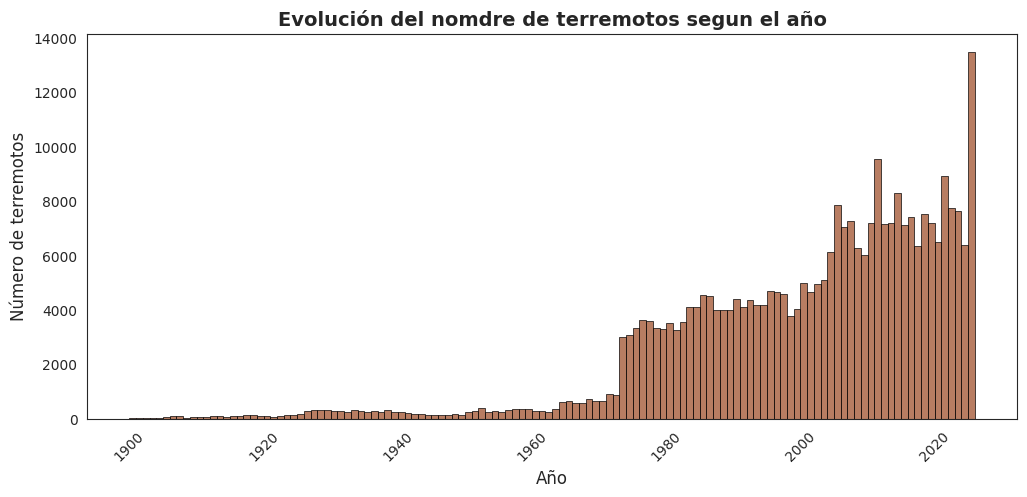

In [105]:
plt.figure(figsize=(12, 5))

sns.histplot(data=data, x='year', binwidth=1, color='sienna', edgecolor='black')

plt.title("Evolución del nomdre de terremotos segun el año", fontsize=14, fontweight='bold')
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número de terremotos", fontsize=12)
plt.xticks(rotation=45)
plt.show()

El número de terremotos registrados aumenta considerablemente a lo largo del tiempo, con un cambio especialmente marcado a partir de la década de 1970. Sin embargo, este aumento puede estar relacionado tanto con una mayor actividad sísmica como con una mejora en la capacidad de detección. Por ello, planteamos la siguiente pregunta: ¿Qué tan representativo es el incremento en el volumen de sismos registrados respecto al comportamiento real del fenómeno sísmico?

ANALIZAR LA MUESTRA

---



In [65]:
print(data['place'].value_counts(dropna=False))

place
South Sandwich Islands region            6644
south of the Fiji Islands                5288
Kermadec Islands region                  4537
Fiji region                              3153
south of the Kermadec Islands            3045
                                         ... 
British Columbia-Yukon border, Canada       1
Near the coast of Ecuador                   1
Off the coast of Hokkaido, Japan            1
Near the coast of El Salvador               1
Near the coast of Venezuela                 1
Name: count, Length: 155481, dtype: int64


La variable place contiene numerosas localizaciones geográficas que permiten identificar ciertas regiones o zonas sísmicas. Sin embargo, una gran parte de los registros corresponde a lugares muy específicos o a zonas que no pueden agruparse fácilmente, por lo que esta variable no es adecuada para analizar directamente toda la muestra.

In [66]:
print(data['magType'].value_counts(dropna=False))

magType
mb            233504
mw             27032
mwc            20330
mww            14060
ms              4558
mwr             3478
mwb             3165
ml              2910
md               800
m                302
mh                92
uk                65
mB                59
fa                36
mfa               34
mblg              19
mlr               14
mint              13
lg                10
mwp                8
Mw                 7
Ml                 6
Md                 6
mc                 5
mj                 4
Mb                 4
mb_lg              3
ms_20              3
mlg                3
ma                 2
NaN                1
ml(texnet)         1
ms_vx              1
Name: count, dtype: int64


La magnitud se calcula mediante diferentes métodos, siendo mb, mw, ms y ml los más representados en la base (nb datos>1000). Para las magnitudes intermedias, las valores son comparables, la diferencia solo et de una décima o una centésima. Sin embargo, las valores de magnitudes pueden ser mas diferentes segun el metodo, para los grandes y pequenas magnitudes (hasta un unidad de differencia). En particular, los terremotos de magnitud inferior a 4 o 5 están principalmente asociados al método ml.

In [67]:
print(data['status'].value_counts(dropna=False))

status
reviewed     310384
automatic       151
Name: count, dtype: int64


La gran mayoría de los registros están en estado "reviewed", lo que significa que un sismólogo revisó y confirmó la información del sismo. Solo una pequeña cantidad es "automatic", lo que indica que los datos fueron procesados únicamente por un algoritmo informático sin verificación humana.

Media en el mundo :  4.933982409587395
Mediana en el mundo :  4.8
Desviación típica en el mundo :  0.4826410762346199


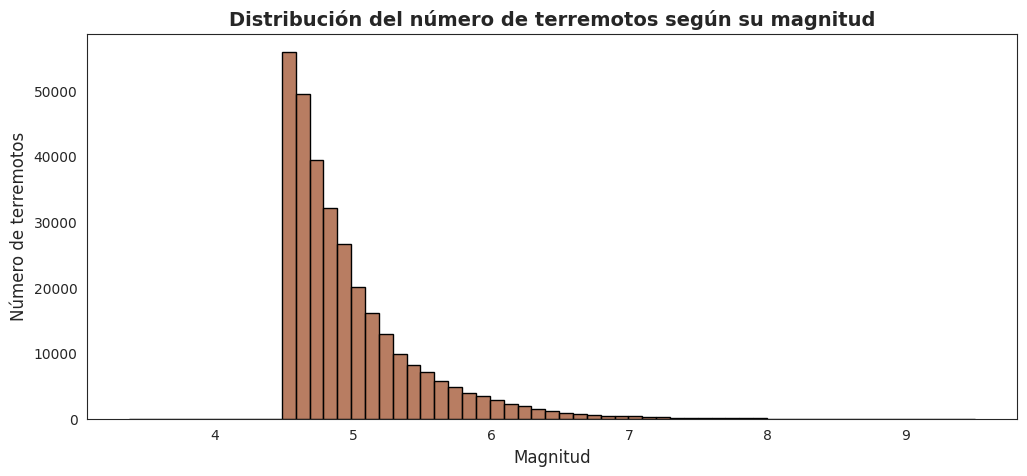

In [88]:
print("Media en el mundo : ", data["mag"].mean())
print("Mediana en el mundo : ", data["mag"].median())
print("Desviación típica en el mundo : ", data["mag"].std())

plt.figure(figsize=(12, 5))

sns.histplot(data=data, x='mag', binwidth=0.1, color='sienna', edgecolor='black')

plt.title("Distribución del número de terremotos según su magnitud", fontsize=14, fontweight='bold')
plt.xlabel("Magnitud", fontsize=12)
plt.ylabel("Número de terremotos", fontsize=12)
plt.show()

La distribución presenta una concentración muy marcada entre aproximadamente 4,5 y 5,0, y luego disminuye progresivamente para las magnitudes más altas. Sin embargo, prácticamente no hay ningún valor inferior a 4,5. Aunque esta ausencia podría estar relacionada con los métodos de medición utilizados, estos no parecen, por sí solos, explicar por completo la forma de la distribución.

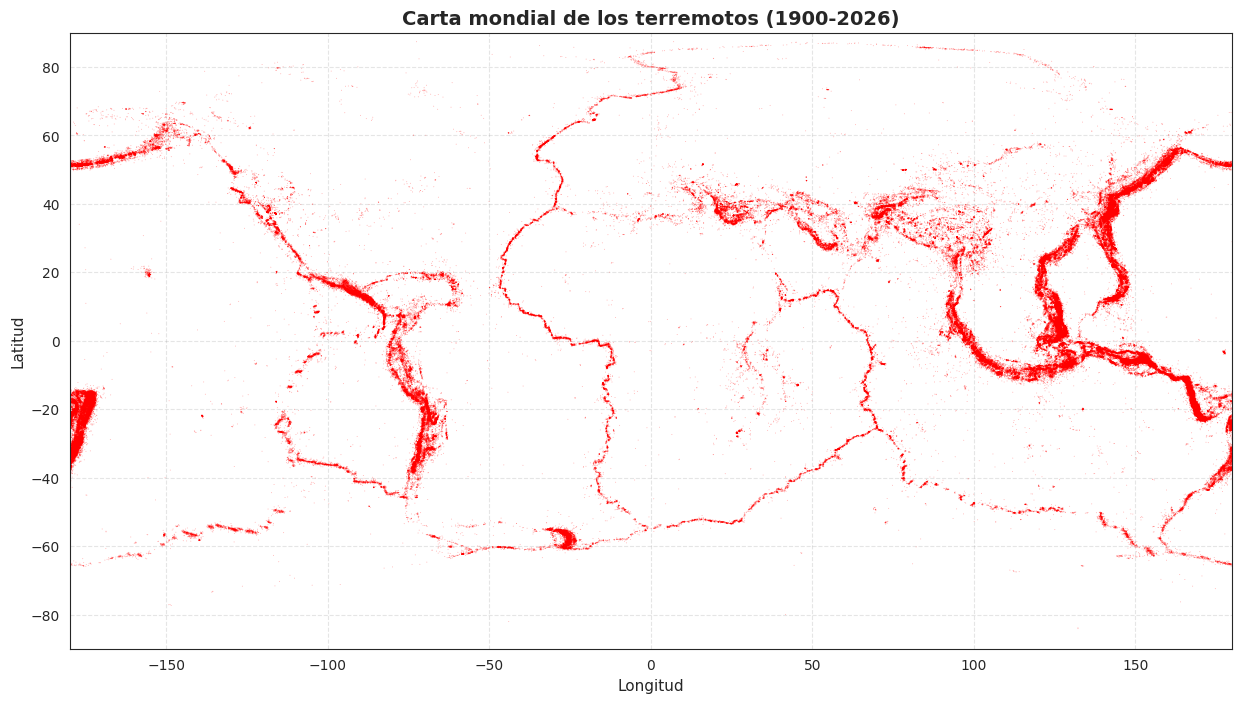

In [69]:
plt.figure(figsize=(15, 8))
ax = plt.gca()

plt.scatter(data["longitude"],data["latitude"],color="red",s=0.5,alpha=0.3,edgecolors="none")

plt.title(
    "Carta mondial de los terremotos (1900-2026)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Longitud", fontsize=11)
plt.ylabel("Latitud", fontsize=11)

plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(True, linestyle="--", alpha=0.2, color="gray")

plt.show()

La distribución espacial de los terremotos coincide con las principales zonas de actividad tectónica, especialmente a lo largo de los límites de placas. Además, los registros están distribuidos a escala mundial, por lo que el conjunto de datos no parece estar concentrado en una única región geográfica.

In [70]:
print(data['decade'].value_counts(dropna=False))

decade
2010    75086
2000    60387
2020    50688
1990    43031
1980    39648
1970    25781
1960     4956
1950     3143
1930     2781
1920     1909
1940     1681
1910      982
1900      462
Name: count, dtype: int64


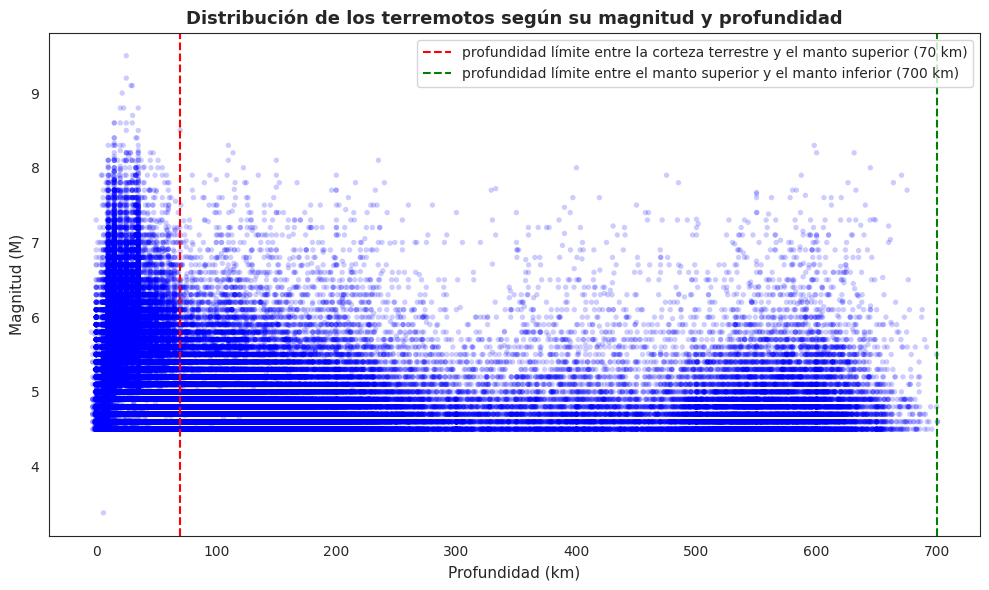

In [90]:
plt.figure(figsize=(10, 6))

plt.scatter(
    data["depth"],
    data["mag"],
    alpha=0.2,
    c="blue",
    edgecolors="none",
    s=15,
)

plt.axvline(70,color="red",linestyle="--",linewidth=1.5,label="profundidad límite entre la corteza terrestre y el manto superior (70 km)")
plt.axvline(700,color="green",linestyle="--",linewidth=1.5,label="profundidad límite entre el manto superior y el manto inferior (700 km)")

plt.title(
    "Distribución de los terremotos según su magnitud y profundidad",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Profundidad (km)", fontsize=11)
plt.ylabel("Magnitud (M)", fontsize=11)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

Este gráfico es interesante porque refleja la estructura de nuestro planeta. En la superficie (menos de 70 km), las rocas son frías y duras, por lo que se rompen fácilmente y generan casi todos los sismos. Más abajo hace tanto calor que la roca se vuelve más blanda y flexible, así que no se rompe con frecuencia. Por eso casi no hay terremotos después de los 700 km: a esa profundidad es físicamente imposible romper la roca.

ANALIZAR LOS DATOS QUE PERMITEN RESPONDER A LA PROBLEMÁTICA


---



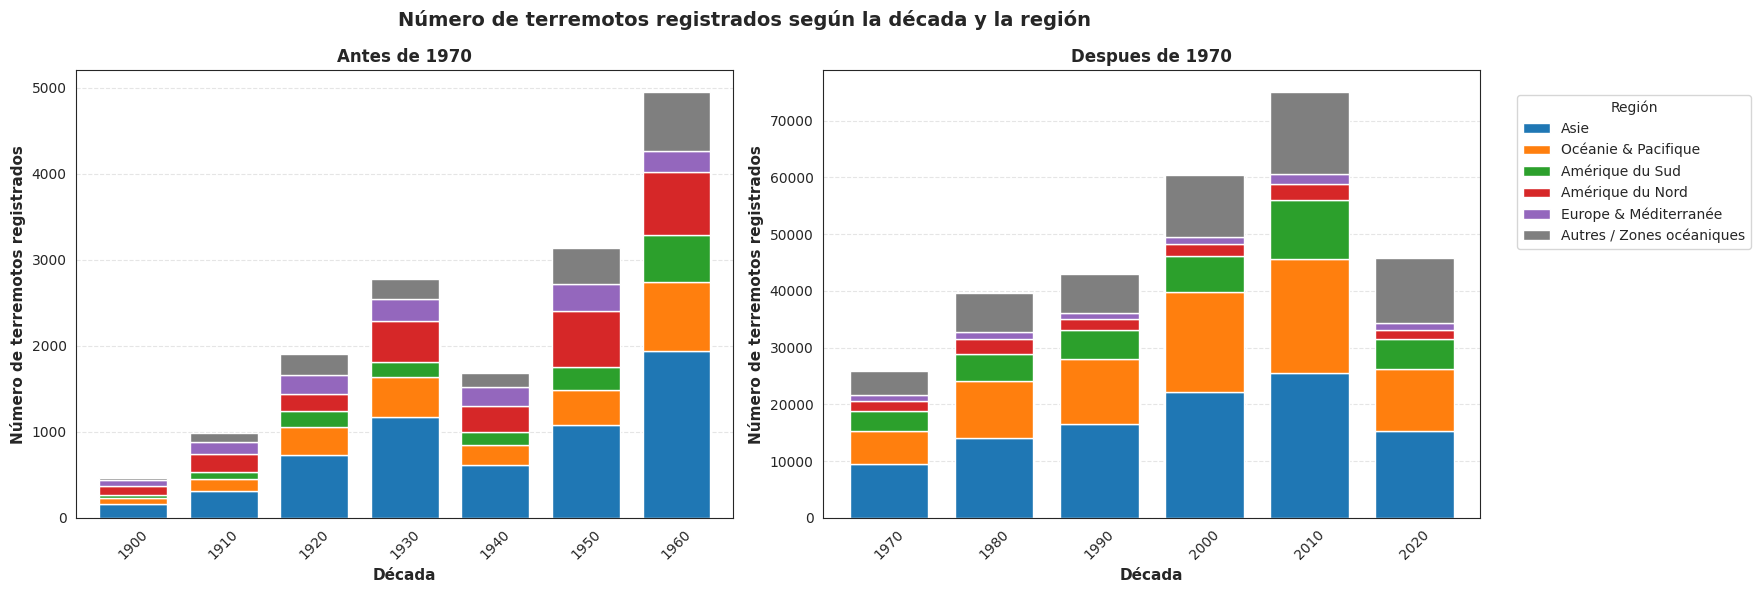

In [72]:
def attribuer_region(row):
    lat, lon = row["latitude"], row["longitude"]
    if lat > 15 and -170 <= lon <= -50:
        return "Amérique du Nord"
    elif lat <= 15 and -120 <= lon <= -30:
        return "Amérique du Sud"
    elif lat > 35 and -25 <= lon <= 45:
        return "Europe & Méditerranée"
    elif lat > 0 and 45 < lon <= 180:
        return "Asie"
    elif lat <= 0 and 40 < lon <= 180:
        return "Océanie & Pacifique"
    else:
        return "Autres / Zones océaniques"


data["region"] = data.apply(attribuer_region, axis=1)

df_region_time = (
    data[data["year"] <= 2025]
    .groupby(["decade", "region"])
    .size()
    .unstack(fill_value=0)
)

regions_order = [
    "Asie",
    "Océanie & Pacifique",
    "Amérique du Sud",
    "Amérique du Nord",
    "Europe & Méditerranée",
    "Autres / Zones océaniques",
]

df_region_time = df_region_time[regions_order]


years = [int(str(idx)[:4]) for idx in df_region_time.index]


df_before_1970 = df_region_time[[y < 1970 for y in years]]
df_after_1970 = df_region_time[[y >= 1970 for y in years]]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#7f7f7f"]


df_before_1970.plot(
    kind="bar", stacked=True, ax=ax1, color=colors, width=0.75, legend=False
)
ax1.set_title("Antes de 1970", fontsize=12, fontweight="bold")
ax1.set_xlabel("Década", fontsize=11, fontweight="bold")
ax1.set_ylabel(
    "Número de terremotos registrados", fontsize=11, fontweight="bold"
)
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, linestyle="--", alpha=0.5, axis="y")

df_after_1970.plot(
    kind="bar", stacked=True, ax=ax2, color=colors, width=0.75, legend=False
)
ax2.set_title("Despues de 1970", fontsize=12, fontweight="bold")
ax2.set_xlabel("Década", fontsize=11, fontweight="bold")
ax2.set_ylabel(
    "Número de terremotos registrados", fontsize=11, fontweight="bold"
)
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = ax2.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Región",
    bbox_to_anchor=(1.01, 0.85),
    loc="upper left",
    frameon=True,
)

fig.suptitle(
    "Número de terremotos registrados según la década y la región",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

El número de terremotos registrados aumenta fuertemente con el tiempo en todas las regiones consideradas. Aunque las regiones presentan diferentes volúmenes de registros, ninguna muestra por sí sola un aumento que explique completamente el cambio observado a partir de la década de 1970. Por lo tanto, la evolución temporal parece estar relacionada con un cambio más general en el registro de los terremotos.

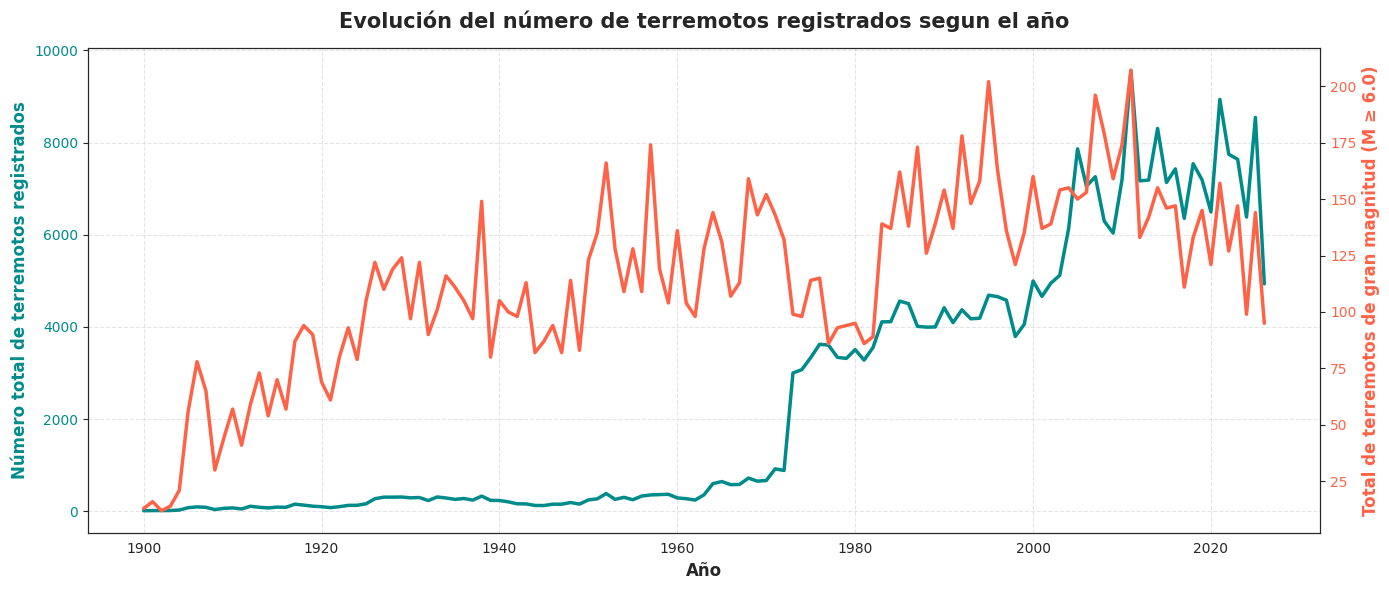

In [94]:
year_counts = data.groupby('year').size()
major_counts = data[data['mag'] >= 6.0].groupby('year').size()

df_trends = pd.DataFrame({
    'Total': year_counts,
    'Major (M>=6.0)': major_counts
}).fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'darkcyan'
color2 = 'tomato'

ax1.set_xlabel('Año', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número total de terremotos registrados', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_trends.index, df_trends['Total'], color=color1, linewidth=2.5, label='Tous les séismes (Volume total)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)


ax2 = ax1.twinx()
ax2.set_ylabel('Total de terremotos de gran magnitud (M ≥ 6.0)', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df_trends.index, df_trends['Major (M>=6.0)'], color=color2, linewidth=2.5, linestyle='-', label='Séismes majeurs (M ≥ 6.0)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evolución del número de terremotos registrados segun el año', fontsize=15, fontweight='bold', pad=15)


plt.tight_layout()
plt.show()

El número total de terremotos registrados aumenta mucho más que el número de terremotos de magnitud igual o superior a 6. Esto indica que el aumento de registros afecta principalmente a los terremotos de menor magnitud, mientras que la cantidad de terremotos grandes presenta una variación mucho menor. Por lo tanto, una parte importante del aumento observado puede estar relacionada con una mayor capacidad para detectar terremotos pequeños.

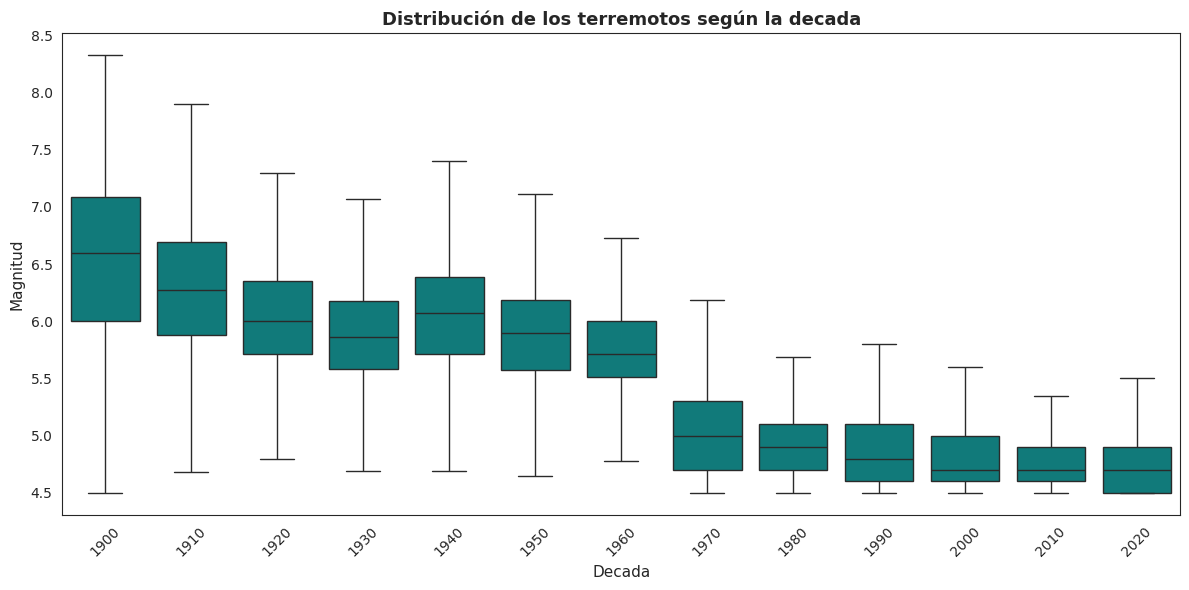

In [97]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data,x="decade",y="mag",color="darkcyan",showfliers=False,)

plt.title("Distribución de los terremotos según la decada", fontsize=13, fontweight="bold")
plt.xlabel("Decada", fontsize=11)
plt.ylabel("Magnitud", fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [98]:
data_deuxmil = data[data["decade"].isin([2000, 2010])]

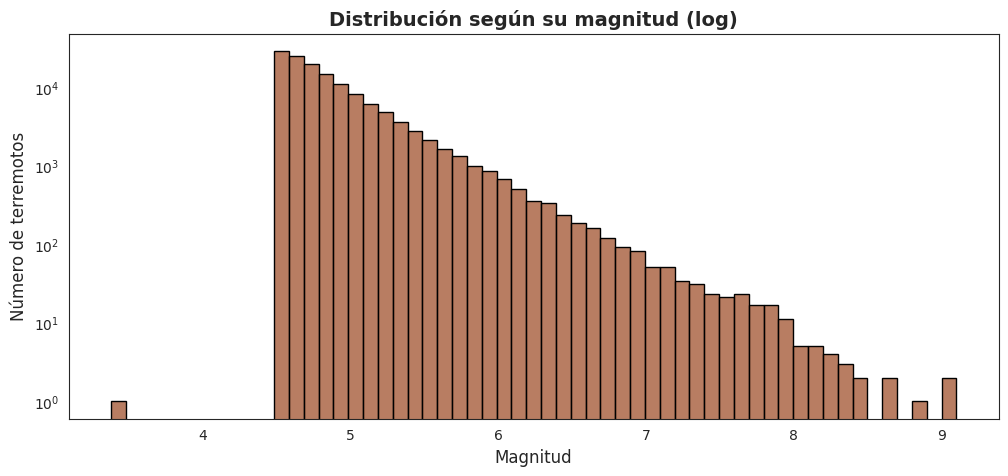

In [106]:
plt.figure(figsize=(12, 5))

sns.histplot(data=data_deuxmil, x='mag', binwidth=0.1, color='sienna', edgecolor='black')
plt.yscale('log')

plt.title("Distribución según su magnitud (log)", fontsize=14, fontweight='bold')
plt.xlabel("Magnitud", fontsize=12)
plt.ylabel("Número de terremotos", fontsize=12)
plt.show()

En una escala logarítmica, la disminución del número de terremotos registrados desde 2000 à 2020 con la magnitud es aproximadamente lineal hasta magnitudes cercanas a 7. A partir de este valor aparece una desviación clara de esta tendencia, con muchos menos registros de los que sugeriría la relación observada para magnitudes menores.

CONTEXTUALISACION - America del sur


---



In [77]:
data_sa = data[data["region"] == "Amérique du Sud"]

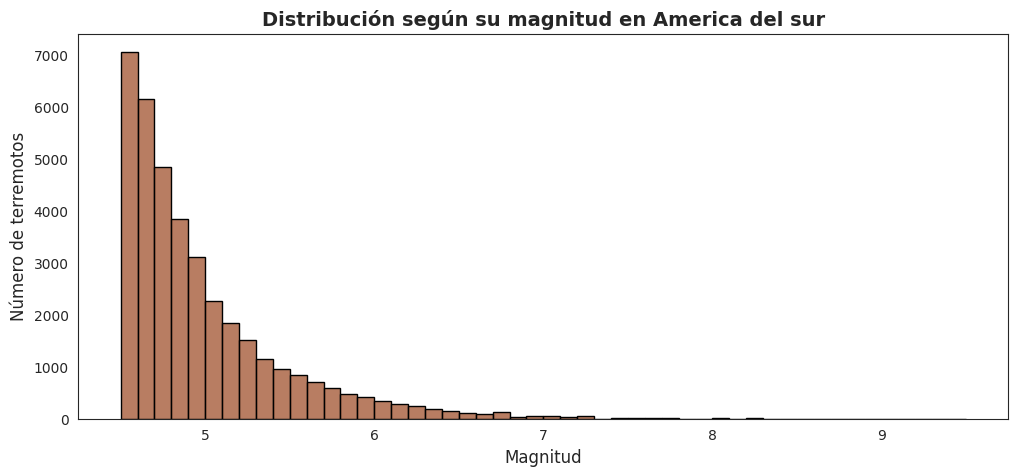

In [102]:
plt.figure(figsize=(12, 5))

sns.histplot(data=data_sa, x='mag', binwidth=0.1, color='sienna', edgecolor='black')

plt.title("Distribución según su magnitud en America del sur", fontsize=14, fontweight='bold')
plt.xlabel("Magnitud", fontsize=12)
plt.ylabel("Número de terremotos", fontsize=12)
plt.show()

In [79]:
print("Media en Sudamérica : ", data_sa["mag"].mean())
print("Mediana en Sudamérica : ", data_sa["mag"].median())
print("Desviación típica en Sudamérica : ", data_sa["mag"].std())

Media en Sudamérica :  4.932595872559969
Mediana en Sudamérica :  4.8
Desviación típica en Sudamérica :  0.4959317409863414


Se observa que el comportamiento global y local de la actividad sísmica es relativamente similar. De hecho, hemos llevado a cabo este trabajo de análisis de las series temporales y el estudio de la media, la mediana y la desviación típica, y hemos obtenido resultados muy similares.

La única diferencia importante que cabe destacar es el número de terremotos anuales, que varía más o menos según las regiones. Por ejemplo, en Europa se registran, de media, cuatro veces menos terremotos que en Sudamérica.


RESULTADO INESPERADO

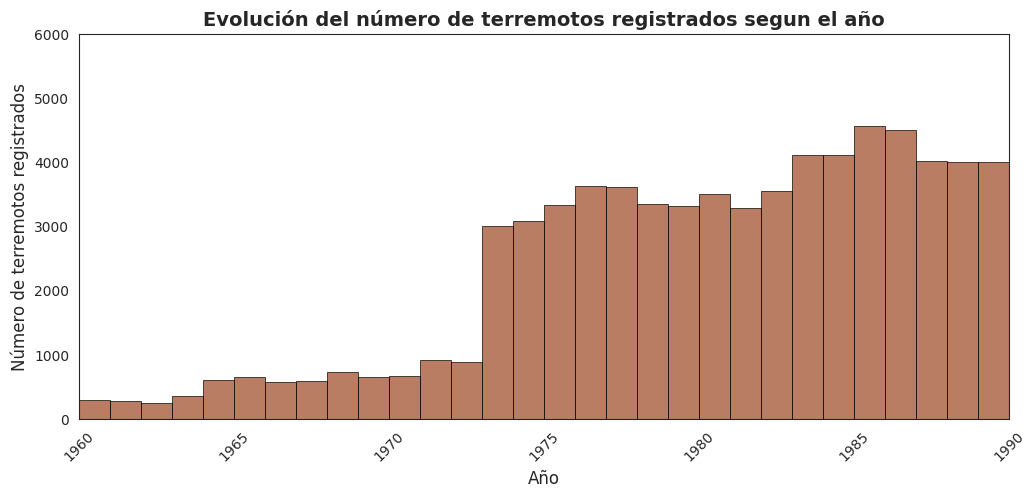

In [103]:
plt.figure(figsize=(12, 5))

sns.histplot(data=data, x='year', binwidth=1, color='sienna', edgecolor='black')

plt.title("Evolución del número de terremotos registrados segun el año", fontsize=14, fontweight='bold')
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número de terremotos registrados", fontsize=12)
plt.xlim(1960,1990)
plt.ylim(0,6000)
plt.xticks(rotation=45)
plt.show()

In [81]:
fractura = data[data["year"].isin([1972, 1973])].groupby("year").size()
print(fractura)

year
1972     887
1973    3001
dtype: int64


Observación: entre 1972 y 1973, el número de terremotos registrados aumenta de forma muy brusca, pasando de menos de 1 000 a alrededor de 3 000 registros anuales. Este cambio es inesperado porque no se observa un aumento comparable en las décadas anteriores.

Hipótesis: una posible explicación es una nueva técnica de detección, por ejemplo mediante la digitalización de los registros o un nuevo programo de expansión de las redes sísmicas.

Evidencia necesaria: para comprobar esta hipótesis sería necesario conocer la evolución histórica de las redes sísmicas, de los instrumentos y de los métodos de procesamiento utilizados.

Gracias a algunas pequeñas investigaciones, encontramos una red implemento entre 60 y 70, el WWSN, pero nadie que podria explicar todo el phenomeno.


FIGURA CLAVE

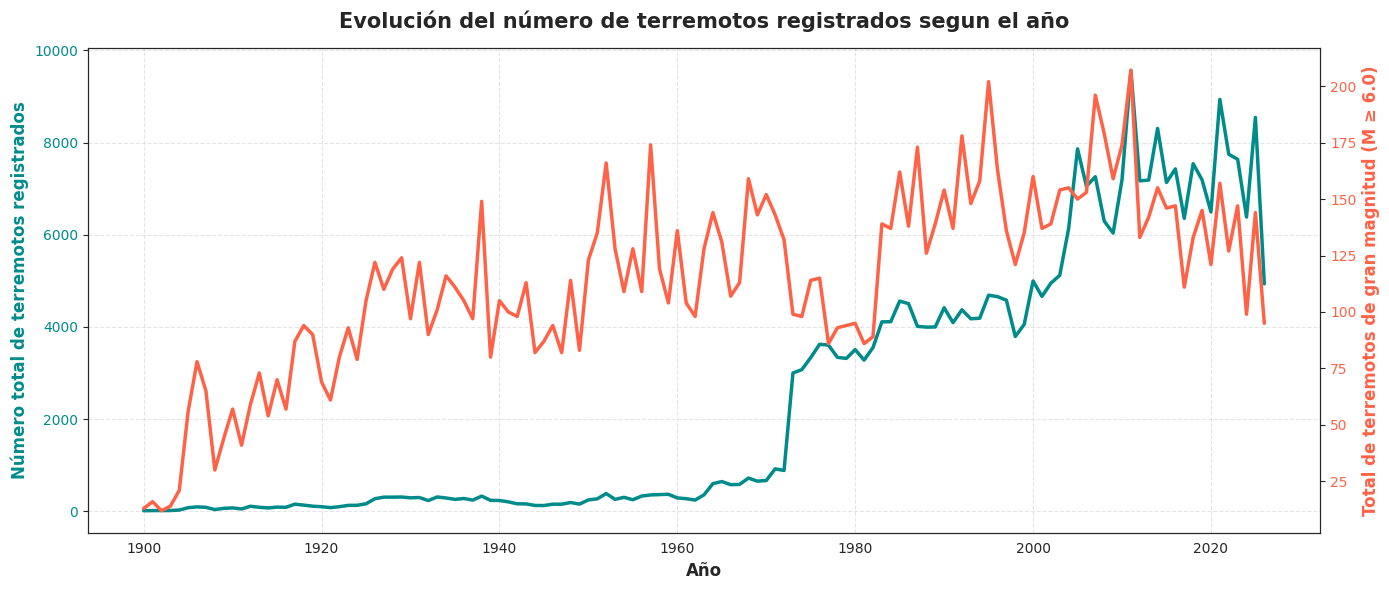

In [104]:
year_counts = data.groupby('year').size()
major_counts = data[data['mag'] >= 6.0].groupby('year').size()

df_trends = pd.DataFrame({
    'Total': year_counts,
    'Major (M>=6.0)': major_counts
}).fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'darkcyan'
color2 = 'tomato'

ax1.set_xlabel('Año', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número total de terremotos registrados', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_trends.index, df_trends['Total'], color=color1, linewidth=2.5, label='Tous les séismes (Volume total)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.set_ylabel('Total de terremotos de gran magnitud (M ≥ 6.0)', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df_trends.index, df_trends['Major (M>=6.0)'], color=color2, linewidth=2.5, linestyle='-', label='Séismes majeurs (M ≥ 6.0)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evolución del número de terremotos registrados segun el año', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

Esta figura es clave porque compara directamente el total de sismos con los más grandes. Mientras el registro general sube de forma drástica, los grandes terremotos se mantienen estables a lo largo del tiempo. Esta diferencia es la mejor prueba de que el aumento de datos está ligado a la mejora en la detección y no a un cambio real en la Tierra.

ANÁLISIS

Los resultados del análisis no permiten afirmar que actualmente ocurran más terremotos que en el pasado. El número de terremotos registrados aumenta fuertemente con el tiempo, pero este aumento es mucho más importante para los terremotos de menor magnitud que para los terremotos grandes. Además, la ruptura observada alrededor de la década de 1970 aparece en varias regiones y coincide con un fuerte aumento del número total de registros, lo que sugiere que una mejora en la capacidad de detección puede explicar esta evolución.

Por lo tanto, los datos muestran claramente un aumento del número de terremotos registrados, pero no permiten separar este efecto de un posible cambio en la actividad sísmica real. Para responder completamente a la pregunta sería necesario disponer de información sobre la evolución de las redes sísmicas, los instrumentos utilizados y los métodos de detección durante el período estudiado.

MODELO DE MACHINE LEARNING

Podemos crear un modelo binario para clasificar terremotos en superficiales o profundos. Esta idea aprovecha el límite físico de la corteza que vimos en la gráfica y representa un problema real de clases desequilibradas. Para desarrollarlo, algunas ideas son usar la localización y la magnitud con un modelo sencillo como un árbol de decisión. Para evaluar los resultados, podríamos probar métricas como el F1-score o la matriz de confusión en vez de usar solo la accuracy.


CONCLUISION

Este análisis nos permitió observar que un aumento en el número de registros no significa necesariamente un aumento equivalente del fenómeno estudiado. El análisis temporal, espacial y por magnitud permitió identificar patrones importantes y, sobre todo, detectar el fuerte cambio en los registros a partir de la década de 1970. También vimos que algunas variables presentan limitaciones, especialmente los diferentes métodos de medición de la magnitud y la información incompleta sobre las condiciones de detección.

Una de las principales limitaciones del análisis es que no conocemos suficientemente la evolución de los instrumentos y de las redes sísmicas durante todo el período. Por esta razón, nuestras conclusiones se refieren principalmente a la evolución de los terremotos registrados y no directamente a la evolución de la actividad sísmica real.

Nosotros utilisamos software de traducion y el IA para la generacion de los graficos complejos.